# 03 · Low-level PCA + multitask training (Experiment 3)
**Question:** does the low-level branch add information without hurting CLIP retrieval?

In [1]:
# Run from the PROJECT ROOT so relative paths (configs/, data/, outputs/)
# resolve exactly like the scripts do — this avoids a notebooks/data/... mismatch.
import sys, os
_root = os.getcwd()
while _root != os.path.dirname(_root):
    if os.path.isdir(os.path.join(_root, 'src')) and os.path.isdir(os.path.join(_root, 'configs')):
        break
    _root = os.path.dirname(_root)
os.chdir(_root)
sys.path.insert(0, _root)
print('project root:', os.getcwd())
import numpy as np
import matplotlib.pyplot as plt
from src.utils import load_config
import pickle
from src.utils import vae_pca_model_path, load_json
cfg = load_config('configs/exp03_lowlevel_multitask_sd21.yaml')
from src.data import FmriDataModule
dm = FmriDataModule(cfg).prepare()

project root: c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion
08:07:58 | INFO    | datamodule | Loading cached split metadata: data\processed\metadata_subj01.csv
08:07:58 | INFO    | datamodule | Prepared 1 subject(s) ['subj01'] | test_split=official | samples: {'train': np.int64(8857), 'val': np.int64(984), 'test': np.int64(159)} | voxels: {'subj01': 39548}


## PCA explained variance of the VAE latents
(Run `scripts/04_precompute_vae_pca.py` first.)

Ejemplo con SD 2.1: `python scripts/04_precompute_vae_pca.py --config configs/exp03_lowlevel_multitask_sd21.yaml`

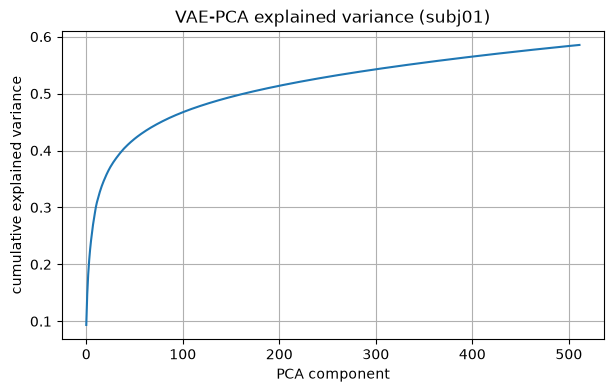

In [2]:
subj = dm.subjects[0]
evr = load_json(str(vae_pca_model_path(cfg, subj)).replace('.pkl','.evr.json'))
plt.figure(figsize=(7,4))
plt.plot(np.cumsum(evr['explained_variance_ratio']))
plt.xlabel('PCA component'); plt.ylabel('cumulative explained variance')
plt.title(f'VAE-PCA explained variance ({subj})'); plt.grid(True); plt.show()

## Train the multitask model
Same `run_training` as `scripts/05_train_multitask.py` (resumable).

In [3]:
from src.training import train_multitask
cfg['training']['epochs'] = 20
result = train_multitask(cfg, resume=None)
result['metrics']

08:08:01 | INFO    | train | Experiment dir: outputs\exp03_lowlevel_multitask_sd21 | device: cuda | lowlevel: True
08:08:01 | INFO    | datamodule | Loading cached split metadata: data\processed\metadata_subj01.csv
08:08:01 | INFO    | datamodule | Prepared 1 subject(s) ['subj01'] | test_split=official | samples: {'train': np.int64(8857), 'val': np.int64(984), 'test': np.int64(159)} | voxels: {'subj01': 39548}
08:08:02 | INFO    | train | Starting training from scratch (no resume).
08:08:17 | INFO    | trainer |   epoch 0 it 0/138 | loss 8.4886
08:08:21 | INFO    | trainer |   epoch 0 it 50/138 | loss 7.0177
08:08:25 | INFO    | trainer |   epoch 0 it 100/138 | loss 6.4938


c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion\.tfm_fmri_diffusion_3_11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


08:08:56 | INFO    | train | epoch 0 | train 6.2363 | val_loss 5.1191 | val_top5 0.4228 * | 54s
08:09:11 | INFO    | trainer |   epoch 1 it 0/138 | loss 5.0719
08:09:15 | INFO    | trainer |   epoch 1 it 50/138 | loss 4.8544
08:09:18 | INFO    | trainer |   epoch 1 it 100/138 | loss 4.8288
08:09:46 | INFO    | train | epoch 1 | train 4.7933 | val_loss 4.7268 | val_top5 0.5407 * | 50s
08:10:00 | INFO    | trainer |   epoch 2 it 0/138 | loss 4.1317
08:10:04 | INFO    | trainer |   epoch 2 it 50/138 | loss 4.0076
08:10:08 | INFO    | trainer |   epoch 2 it 100/138 | loss 4.0117
08:10:35 | INFO    | train | epoch 2 | train 4.0108 | val_loss 4.5251 | val_top5 0.5955 * | 49s
08:10:49 | INFO    | trainer |   epoch 3 it 0/138 | loss 3.3949
08:10:53 | INFO    | trainer |   epoch 3 it 50/138 | loss 3.3923
08:10:57 | INFO    | trainer |   epoch 3 it 100/138 | loss 3.4026
08:11:24 | INFO    | train | epoch 3 | train 3.4180 | val_loss 4.5036 | val_top5 0.6189 * | 49s
08:11:38 | INFO    | trainer | 

{'val': {'retrieval': {'top1': 0.29573170731707316,
   'top5': 0.6189024390243902,
   'top10': 0.7378048780487805,
   'mean_rank': 11.075203252032521,
   'mean_cosine': 0.5275822281837463},
  'embedding': {'mse': 1.7883889376310516,
   'mae': 0.9937817041894994,
   'mean_cosine': 0.5275822619244911,
   'r2': -7.4634851647717895,
   'mean_pearson': 0.3853610627227509,
   'median_pearson': 0.3726012084097674,
   'n': 984,
   'dim': 768},
  'loss': 4.503594534183906,
  'lowlevel': {'mse': 10.140707139756563,
   'mae': 1.7082042375248603,
   'mean_cosine': 0.4196817463425089,
   'r2': 0.19114653753279987,
   'mean_pearson': 0.05197028576234991,
   'median_pearson': 0.027440378367479056,
   'n': 984,
   'dim': 512}},
 'test': {'retrieval': {'top1': 0.5220125786163522,
   'top5': 0.8930817610062893,
   'top10': 0.9748427672955975,
   'mean_rank': 3.150943396226415,
   'mean_cosine': 0.5239031314849854},
  'embedding': {'mse': 1.764211814920856,
   'mae': 0.9897756819750926,
   'mean_cosine':

## CLIP-only vs multitask retrieval

In [4]:
clip_only = load_json('outputs/exp01_fmri_to_clip/metrics/test_metrics.json')['retrieval']
multitask = result['metrics']['test']['retrieval']
import pandas as pd
pd.DataFrame({'clip_only': clip_only, 'multitask': multitask})

,clip_only,multitask
top1,0.471698,0.522013
top5,0.867925,0.893082
top10,0.955975,0.974843
mean_rank,3.459119,3.150943
mean_cosine,0.535735,0.523903


## Low-level prediction quality (per-PCA-component Pearson)

In [5]:
%matplotlib inline

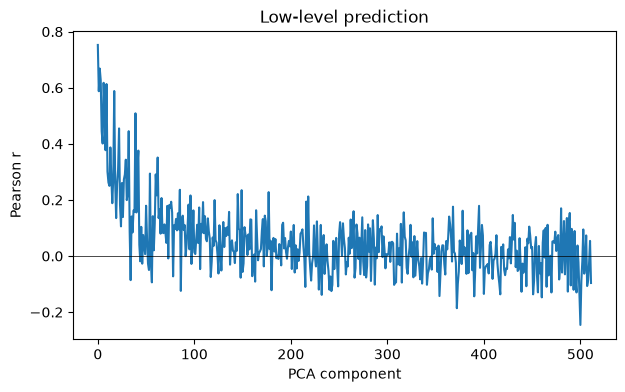

mean Pearson r = 0.052


In [7]:
import torch
from src.evaluation import load_subject_matrices, per_component_pearson
from src.models import build_model_from_checkpoint
from src.utils import get_device
device = get_device(cfg.get('runtime.device','auto'))
model,_ = build_model_from_checkpoint(cfg, 'outputs/exp03_lowlevel_multitask/checkpoints/best.pt', device, dm.voxel_counts)
m = load_subject_matrices(cfg, dm, subj, 'test', want=('fmri','low'))
with torch.no_grad():
    low_pred = model(torch.from_numpy(m.fmri).float().to(device), subject=subj)['low'].cpu().numpy()
r = per_component_pearson(low_pred, m.low)
plt.figure(figsize=(7,4)); plt.plot(r); plt.axhline(0, color='k', lw=0.5)
plt.xlabel('PCA component'); plt.ylabel('Pearson r'); plt.title('Low-level prediction'); plt.show()
print('mean Pearson r = %.3f' % np.nanmean(r))

**Takeaway:** the multitask model should keep (or improve) CLIP retrieval while predicting low-level components above a mean/zero baseline (positive Pearson r).